In [1]:
# %pip install matplotlib

In [2]:
# %pip install seaborn

In [1]:
import numpy as np
import pandas as pd
import matplotlib as plt
import seaborn as sns

In [2]:
df = pd.read_csv('Datasets/email_data.csv')
df

,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\nth...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\n( see a...",0
2,3624,ham,"Subject: neon retreat\nho ho ho , we ' re arou...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\nthis deal is to ...,0
...,...,...,...,...
5166,1518,ham,Subject: put the 10 on the ft\nthe transport v...,0
5167,404,ham,Subject: 3 / 4 / 2000 and following noms\nhpl ...,0
5168,2933,ham,Subject: calpine daily gas nomination\n>\n>\nj...,0
5169,1409,ham,Subject: industrial worksheets for august 2000...,0


Create a model that can predict/classify spam mails based upon the given historical data.

spam - 1 <br>
ham - 0 <br>

Target column - label <br>

Since target is categorical, it is a classification problem.


## EDA

In [3]:
# attributes

df.columns

# Unnamed: 0 is not needed

Index(['Unnamed: 0', 'label', 'text', 'label_num'], dtype='object')

In [4]:
# check the count/distribution of spam vs ham. This would be helpful in identifying imbalanced data.

df.value_counts('label_num')

label_num
0    3672
1    1499
Name: count, dtype: int64

In [5]:
df.value_counts('label_num', normalize=True) * 100

# 28% are spam mails

label_num
0    71.01141
1    28.98859
Name: proportion, dtype: float64

In [6]:
# Imbalanced Data

# Ideal -> 50/50
# Workable -> 60/40
# Improve -> 70/30

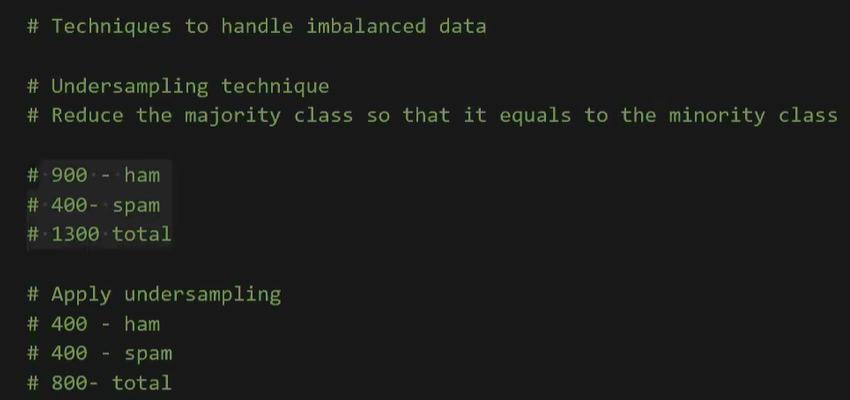


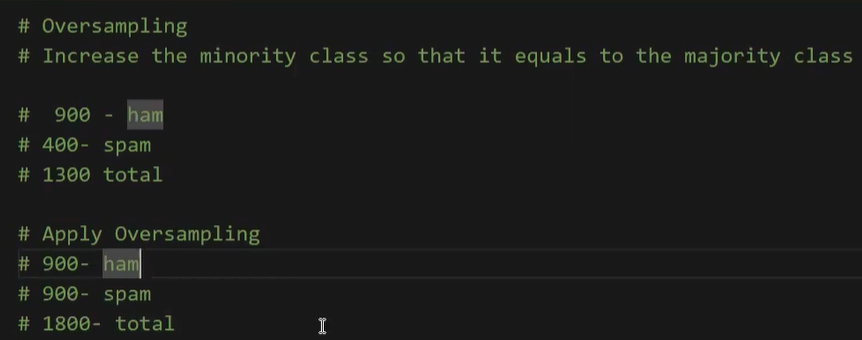


1 rows equals to 1 piece of learning to the model. Every unique row is 1 piece of learning to it. Duplicate rows don't give any learning to it.

<br>
Both the techniques are not ideal but Oversampling has some edge over Undersampling.


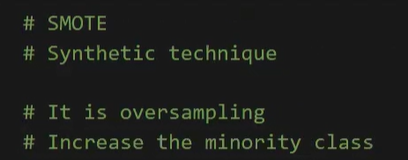

In [7]:
# remove the unwanted columns

df.drop('Unnamed: 0', axis = 1, inplace=True)

In [8]:
df

,label,text,label_num
0,ham,Subject: enron methanol ; meter # : 988291\nth...,0
1,ham,"Subject: hpl nom for january 9 , 2001\n( see a...",0
2,ham,"Subject: neon retreat\nho ho ho , we ' re arou...",0
3,spam,"Subject: photoshop , windows , office . cheap ...",1
4,ham,Subject: re : indian springs\nthis deal is to ...,0
...,...,...,...
5166,ham,Subject: put the 10 on the ft\nthe transport v...,0
5167,ham,Subject: 3 / 4 / 2000 and following noms\nhpl ...,0
5168,ham,Subject: calpine daily gas nomination\n>\n>\nj...,0
5169,ham,Subject: industrial worksheets for august 2000...,0


## Text Preprocessing

In [9]:
import re

In [10]:
# Text Cleaning

def text_cleaner(text):
    text = text.lower()
    text = re.sub(r'[^a-z \n]', '', text)
    text = re.sub(r'[\n]', ' ', text)
    text = re.sub(r'[ ]+',' ', text)
    return text;

In [11]:
df['clean_text'] = df.text.apply(text_cleaner)

In [12]:
df

,label,text,label_num,clean_text
0,ham,Subject: enron methanol ; meter # : 988291\nth...,0,subject enron methanol meter this is a follow ...
1,ham,"Subject: hpl nom for january 9 , 2001\n( see a...",0,subject hpl nom for january see attached file ...
2,ham,"Subject: neon retreat\nho ho ho , we ' re arou...",0,subject neon retreat ho ho ho we re around to ...
3,spam,"Subject: photoshop , windows , office . cheap ...",1,subject photoshop windows office cheap main tr...
4,ham,Subject: re : indian springs\nthis deal is to ...,0,subject re indian springs this deal is to book...
...,...,...,...,...
5166,ham,Subject: put the 10 on the ft\nthe transport v...,0,subject put the on the ft the transport volume...
5167,ham,Subject: 3 / 4 / 2000 and following noms\nhpl ...,0,subject and following noms hpl can t take the ...
5168,ham,Subject: calpine daily gas nomination\n>\n>\nj...,0,subject calpine daily gas nomination julie as ...
5169,ham,Subject: industrial worksheets for august 2000...,0,subject industrial worksheets for august activ...


In [13]:
print(df.text.iloc[0])

Subject: enron methanol ; meter # : 988291
this is a follow up to the note i gave you on monday , 4 / 3 / 00 { preliminary
flow data provided by daren } .
please override pop ' s daily volume { presently zero } to reflect daily
activity you can obtain from gas control .
this change is needed asap for economics purposes .


In [14]:
print(df.clean_text.iloc[0])

subject enron methanol meter this is a follow up to the note i gave you on monday preliminary flow data provided by daren please override pop s daily volume presently zero to reflect daily activity you can obtain from gas control this change is needed asap for economics purposes 


In [15]:
text='Hello                everyone'
text_cleaner(text)

'hello everyone'

In [16]:
# * -> Match all the occurence if the patter is found.
#     Return empty string if the patter is not found.

# + -> Match all the occurence if the patter is found.
#     Return None if the patter is not found.

In [17]:
text='He#llo####friends##!'

for i in re.finditer(r'[#]+',text):
    print(i)

<re.Match object; span=(2, 3), match='#'>
<re.Match object; span=(6, 10), match='####'>
<re.Match object; span=(17, 19), match='##'>


In [18]:
text='He#llo####friends##!'

for i in re.finditer(r'[#]*',text):
    print(i)

<re.Match object; span=(0, 0), match=''>
<re.Match object; span=(1, 1), match=''>
<re.Match object; span=(2, 3), match='#'>
<re.Match object; span=(3, 3), match=''>
<re.Match object; span=(4, 4), match=''>
<re.Match object; span=(5, 5), match=''>
<re.Match object; span=(6, 10), match='####'>
<re.Match object; span=(10, 10), match=''>
<re.Match object; span=(11, 11), match=''>
<re.Match object; span=(12, 12), match=''>
<re.Match object; span=(13, 13), match=''>
<re.Match object; span=(14, 14), match=''>
<re.Match object; span=(15, 15), match=''>
<re.Match object; span=(16, 16), match=''>
<re.Match object; span=(17, 19), match='##'>
<re.Match object; span=(19, 19), match=''>
<re.Match object; span=(20, 20), match=''>


In [19]:
df.head()

,label,text,label_num,clean_text
0,ham,Subject: enron methanol ; meter # : 988291\nth...,0,subject enron methanol meter this is a follow ...
1,ham,"Subject: hpl nom for january 9 , 2001\n( see a...",0,subject hpl nom for january see attached file ...
2,ham,"Subject: neon retreat\nho ho ho , we ' re arou...",0,subject neon retreat ho ho ho we re around to ...
3,spam,"Subject: photoshop , windows , office . cheap ...",1,subject photoshop windows office cheap main tr...
4,ham,Subject: re : indian springs\nthis deal is to ...,0,subject re indian springs this deal is to book...


## Tokenisation

In [20]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer

In [21]:
lem = WordNetLemmatizer()

In [22]:
def tokeniser(text):
    
    def tag_cleaner(tag):
        if (tag.startswith('V')):
            return 'v'
        elif (tag.startswith('J')):
            return 'a'
        elif (tag.startswith('R')):
            return 'r'
        else:
            return 'n'
        
    tokens = word_tokenize(text)
    cleaned_tokens = [token for token in tokens if token not in stopwords.words('english')]
    tokens_with_tags = nltk.pos_tag(cleaned_tokens)
    
    lemmetised_tokens = []
    for token,tag in tokens_with_tags:
        new_tag = tag_cleaner(tag)
        lemmetised_tokens.append(lem.lemmatize(token, new_tag))
    
    return ' '.join(lemmetised_tokens)

In [23]:
tokeniser("hello! how are you? I am really happier")

'hello ! ? I really happier'

In [24]:
df['lemmatised_text'] = df.clean_text.apply(tokeniser)

In [25]:
df

,label,text,label_num,clean_text,lemmatised_text
0,ham,Subject: enron methanol ; meter # : 988291\nth...,0,subject enron methanol meter this is a follow ...,subject enron methanol meter follow note give ...
1,ham,"Subject: hpl nom for january 9 , 2001\n( see a...",0,subject hpl nom for january see attached file ...,subject hpl nom january see attach file hplnol...
2,ham,"Subject: neon retreat\nho ho ho , we ' re arou...",0,subject neon retreat ho ho ho we re around to ...,subject neon retreat ho ho ho around wonderful...
3,spam,"Subject: photoshop , windows , office . cheap ...",1,subject photoshop windows office cheap main tr...,subject photoshop windows office cheap main tr...
4,ham,Subject: re : indian springs\nthis deal is to ...,0,subject re indian springs this deal is to book...,subject indian spring deal book teco pvr reven...
...,...,...,...,...,...
5166,ham,Subject: put the 10 on the ft\nthe transport v...,0,subject put the on the ft the transport volume...,subject put ft transport volume decrease contr...
5167,ham,Subject: 3 / 4 / 2000 and following noms\nhpl ...,0,subject and following noms hpl can t take the ...,subject follow noms hpl take extra mmcf weeken...
5168,ham,Subject: calpine daily gas nomination\n>\n>\nj...,0,subject calpine daily gas nomination julie as ...,subject calpine daily gas nomination julie men...
5169,ham,Subject: industrial worksheets for august 2000...,0,subject industrial worksheets for august activ...,subject industrial worksheet august activity a...


In [26]:
print(df.clean_text.iloc[0])
print(df.lemmatised_text.iloc[0])

subject enron methanol meter this is a follow up to the note i gave you on monday preliminary flow data provided by daren please override pop s daily volume presently zero to reflect daily activity you can obtain from gas control this change is needed asap for economics purposes 
subject enron methanol meter follow note give monday preliminary flow data provide daren please override pop daily volume presently zero reflect daily activity obtain gas control change need asap economics purpose


In [27]:
dict(zip(df.clean_text.iloc[0].split(" "), df.lemmatised_text.iloc[0].split(" ")))

{'subject': 'subject',
 'enron': 'enron',
 'methanol': 'methanol',
 'meter': 'meter',
 'this': 'follow',
 'is': 'note',
 'a': 'give',
 'follow': 'monday',
 'up': 'preliminary',
 'to': 'flow',
 'the': 'data',
 'note': 'provide',
 'i': 'daren',
 'gave': 'please',
 'you': 'override',
 'on': 'pop',
 'monday': 'daily',
 'preliminary': 'volume',
 'flow': 'presently',
 'data': 'zero',
 'provided': 'reflect',
 'by': 'daily',
 'daren': 'activity',
 'please': 'obtain',
 'override': 'gas',
 'pop': 'control',
 's': 'change',
 'daily': 'need',
 'volume': 'asap',
 'presently': 'economics',
 'zero': 'purpose'}

## Text Vectorisation

In [28]:
vectorizer = TfidfVectorizer()

In [29]:
text_vector = vectorizer.fit_transform(df.lemmatised_text).toarray()
text_vector

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(5171, 41933))

In [30]:
df.shape, text_vector.shape
# rows => total number of email subjects
# columnms => vocab - unique words from all the texts

((5171, 5), (5171, 41933))

In [31]:
vectorizer.get_feature_names_out()

array(['aa', 'aaa', 'aabda', ..., 'zzocb', 'zzso', 'zzsyt'],
      shape=(41933,), dtype=object)

In [32]:
documents = [doc for doc in df.lemmatised_text.str.split()]
len(documents)

5171

In [33]:
total_words = []
for doc in documents:
    #print(wordList)
    for word in doc:
            total_words.append(word)

In [34]:
print(len(total_words)) # total no. of words from all documents
print(len(set(total_words))) # total no. of unique words

503338
41957


In [35]:
features = pd.DataFrame(text_vector)
features # means the input data

,0,1,2,3,4,5,6,7,8,9,...,41923,41924,41925,41926,41927,41928,41929,41930,41931,41932
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5166,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5167,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5168,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5169,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [36]:
df['label'].unique()

array(['ham', 'spam'], dtype=object)

In [37]:
df['target'] = df.label.map({'ham': 0, 'spam': 1})

In [38]:
df.target.shape

(5171,)

## Data Split

In [39]:
from sklearn.model_selection import train_test_split

In [40]:
target = df[['target']]

In [41]:
df.target.value_counts(normalize=True)*100

target
0    71.01141
1    28.98859
Name: proportion, dtype: float64

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=45, stratify=target)
# use stratify when there is data imbalance. It makes sure your train and test data has both 0's and 1's (maintains the same ratio).
# X is used to represent the features
# y is used for the target

In [43]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((4136, 41933), (4136, 1), (1035, 41933), (1035, 1))

In [44]:
5171*0.8, 5171*0.2 # 80% training data, 20% testing data

(4136.8, 1034.2)

In [58]:
y_train.target.value_counts(normalize=True)*100

target
0    71.010638
1    28.989362
Name: proportion, dtype: float64

In [59]:
y_test.target.value_counts(normalize=True)*100

target
0    71.014493
1    28.985507
Name: proportion, dtype: float64

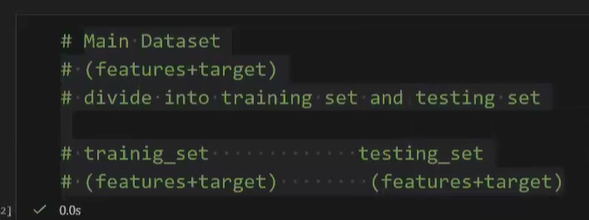

### Explanation with dummy data

In [45]:
dummy_data = pd.DataFrame({'x1': np.random.random(50),
                           'x2': np.random.random(50),
                           'x3': np.random.random(50),
                           'x4': np.random.random(50),
                           'target': np.random.randint(0,2,50)})

In [46]:
dummy_data # 4 features and 1 target

,x1,x2,x3,x4,target
0,0.892291,0.025650,0.420593,0.482766,0
1,0.307480,0.015257,0.991434,0.955745,0
2,0.819145,0.550561,0.653468,0.245804,0
3,0.586500,0.866650,0.356296,0.537501,0
4,0.050396,0.201677,0.212324,0.975038,1
5,0.909033,0.412682,0.004490,0.252065,1
6,0.784570,0.973618,0.414305,0.806210,0
7,0.430631,0.771270,0.379260,0.762356,0
8,0.894873,0.372294,0.644917,0.070946,1
9,0.057178,0.189588,0.515656,0.877632,0


In [47]:
# 45 - training
# 5 - testing

# 90/10 split (training and testing)

In [48]:
dummy_data.sample(45, random_state=45).shape # random 45 samples out of 50

(45, 5)

In [49]:
dummy_data.sample(5, random_state=22).shape 
# random 5 samples out of 50. If we use the same random_state, we will get the first 5 rows of the training data.
# But, we should have a separate testing data which is not part of training (no overlap). So, we use Python's train_test_split feature.

(5, 5)

In [51]:
res = train_test_split(dummy_data[['x1', 'x2', 'x3', 'x4']], dummy_data[['target']], test_size=0.2, random_state=45, stratify=dummy_data[['target']])

In [55]:
res

[          x1        x2        x3        x4
 28  0.804623  0.329384  0.812642  0.981478
 4   0.050396  0.201677  0.212324  0.975038
 8   0.894873  0.372294  0.644917  0.070946
 46  0.102259  0.371569  0.844676  0.651006
 1   0.307480  0.015257  0.991434  0.955745
 7   0.430631  0.771270  0.379260  0.762356
 34  0.830098  0.894183  0.669301  0.633930
 10  0.819590  0.896680  0.953951  0.780476
 23  0.628491  0.431543  0.473105  0.000934
 44  0.356844  0.889232  0.690243  0.269365
 9   0.057178  0.189588  0.515656  0.877632
 17  0.458874  0.123599  0.787077  0.272441
 32  0.143173  0.314860  0.308963  0.112825
 24  0.111761  0.419859  0.788544  0.918691
 36  0.245395  0.103677  0.496527  0.001230
 31  0.097442  0.902241  0.928044  0.428208
 26  0.861562  0.187256  0.315419  0.859286
 43  0.956085  0.911000  0.469409  0.179606
 37  0.669834  0.691517  0.509300  0.122669
 25  0.496486  0.171686  0.290800  0.372629
 12  0.767446  0.054746  0.863748  0.609201
 48  0.465875  0.687631  0.36179

In [52]:
len(res)

4

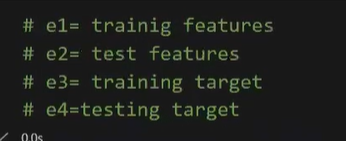

In [54]:
res[0].shape, res[1].shape, res[2].shape, res[3].shape

((40, 4), (10, 4), (40, 1), (10, 1))

## Apply the algorithm (model)

In [60]:
from sklearn.linear_model import LogisticRegression

In [61]:
model = LogisticRegression()

In [62]:
model.fit(X_train, y_train.target)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [63]:
model.coef_

array([[ 0.27191801,  0.01454869, -0.04502032, ...,  0.02435754,
         0.07666377,  0.00514089]], shape=(1, 41933))

## Prediction (test data)

In [78]:
pred = model.predict(X_test)
pred

array([0, 1, 0, ..., 1, 0, 0], shape=(1035,))

In [79]:
for predicted,actual in zip(pred.tolist(), y_test.target.values.tolist()):
    print(predicted, actual, sep="--")

0--0
1--1
0--0
1--1
1--0
0--0
1--1
0--0
0--0
0--0
0--0
0--0
1--1
0--0
0--0
1--1
0--0
0--0
0--0
0--0
0--0
0--0
1--1
0--0
0--0
0--0
0--0
0--0
0--0
0--0
0--0
1--1
1--1
1--1
0--0
0--0
0--0
0--0
0--0
0--0
0--0
0--0
0--0
1--1
1--1
0--0
0--0
0--0
0--0
0--0
1--1
0--0
0--0
1--1
0--0
0--0
0--0
1--1
1--1
0--0
1--1
0--0
0--0
0--0
0--0
0--0
1--1
0--0
0--0
0--0
1--1
1--1
0--0
0--0
0--0
1--1
1--1
1--1
0--0
0--0
0--0
1--1
1--1
0--0
0--0
0--0
0--0
0--0
0--0
0--0
0--0
1--1
0--0
1--1
0--0
1--1
0--0
1--1
0--0
0--1
0--0
0--0
0--0
1--1
0--0
0--0
1--1
0--0
1--1
0--0
1--1
0--0
1--1
0--0
0--0
0--0
0--0
1--1
0--0
1--1
0--0
1--1
0--0
1--1
0--0
0--0
0--0
0--0
0--0
0--0
1--1
0--0
0--0
0--0
0--0
0--0
1--1
1--1
0--0
0--0
1--1
0--0
0--0
1--1
0--0
1--1
0--0
1--1
0--0
0--0
1--1
0--0
0--0
0--0
1--1
1--1
0--0
0--0
0--0
1--1
0--0
0--0
1--1
0--0
0--0
1--1
1--1
1--1
1--1
0--0
1--1
1--1
0--0
1--1
0--0
0--0
0--0
0--0
1--1
1--1
0--0
0--0
1--1
0--0
1--1
1--1
0--0
1--1
0--1
0--0
0--0
0--0
0--0
1--1
0--0
0--0
0--0
1--1
0--0
1--1


In [80]:
model.score(X_test, y_test)

0.9816425120772947

In [83]:
from sklearn.metrics import confusion_matrix, f1_score

In [82]:
confusion_matrix(y_test.target, pred)

array([[720,  15],
       [  4, 296]])

In [84]:
f1_score(y_test, pred)

0.9689034369885434